In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd

# Load the data
df = pd.read_csv("deliveries2.csv")

# Convert datetime columns
df['delivery_finished'] = pd.to_datetime(df['delivery_finished'])
df['delivery_started'] = pd.to_datetime(df['delivery_started'])

# Feature engineering
df['hour'] = df['delivery_finished'].dt.hour
df['day_of_week'] = df['delivery_finished'].dt.dayofweek
df['month'] = df['delivery_finished'].dt.month

# Drop rows with missing values or non-completes
df = df.dropna(subset=['total_delivery_time', 'number_of_obstacles'])
df = df[df['status'] == 'COMPLETED']

# Select features and targets
X = df[['hour', 'day_of_week', 'month','number_of_obstacles']]
y = df[['total_delivery_time']]  # Two target variables

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature preprocessing
feature_transformer = ColumnTransformer([
    ('num', StandardScaler(), ['hour', 'day_of_week', 'month'])
])

# Pipeline with preprocessing and multi-output model
pipeline = Pipeline(steps=[
    ('preprocessor', feature_transformer),
    ('model', MultiOutputRegressor(RandomForestRegressor(random_state=42)))
])

# Hyperparameter grid
param_grid = {
    'model__estimator__n_estimators': [50, 100, 200],
    'model__estimator__max_depth': [None, 10, 20],
    'model__estimator__min_samples_split': [2, 5],
    'model__estimator__min_samples_leaf': [1, 2],
    'model__estimator__max_features': ['sqrt', 'log2']  # Fixed invalid parameter value
}

# Perform grid search
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Get the best model
best_model = grid_search.best_estimator_

# Predict and evaluate
y_pred = best_model.predict(X_test)
mse_time = mean_squared_error(y_test['total_delivery_time'], y_pred[:, 0])
mae_time = mean_absolute_error(y_test['total_delivery_time'], y_pred[:, 0])

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Mean Squared Error (Delivery Time): {mse_time:.2f}")
print(f"Mean Absolute Error (Delivery Time): {mae_time:.2f}")


Best Parameters: {'model__estimator__max_depth': 10, 'model__estimator__max_features': 'sqrt', 'model__estimator__min_samples_leaf': 2, 'model__estimator__min_samples_split': 5, 'model__estimator__n_estimators': 50}
Mean Squared Error (Delivery Time): 18.82
Mean Absolute Error (Delivery Time): 3.60


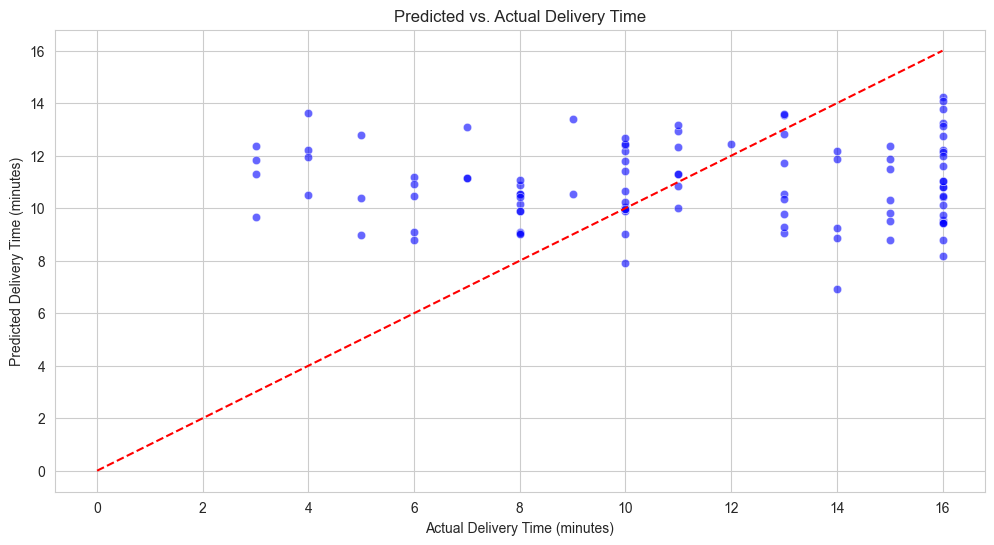

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract predicted values for each output
y_pred_delivery_time = y_pred[:, 0]  # For Delivery Time

# Convert pandas Series to numpy arrays for actual values
y_test_delivery_time = y_test['total_delivery_time'].values

# Scatter plot for Delivery Time
plt.figure(figsize=(12, 6))
sns.scatterplot(x=y_test_delivery_time, y=y_pred_delivery_time, alpha=0.6, color="blue")
plt.plot([0, max(y_test_delivery_time)], [0, max(y_test_delivery_time)], 'r--')  # Ideal line
plt.xlabel("Actual Delivery Time (minutes)")
plt.ylabel("Predicted Delivery Time (minutes)")
plt.title("Predicted vs. Actual Delivery Time")
plt.show()



In [7]:
# New test cases
new_data = pd.DataFrame([
    {'hour': 16, 'day_of_week': 2, 'month': 3},   # Example case
    {'hour': 15, 'day_of_week': 4, 'month': 12}   # Another example case
])

# Make predictions
new_predictions = best_model.predict(new_data)

# Display predictions
for i, row in new_data.iterrows():
    print(
        f"Test Case {i+1}: Hour = {row['hour']}, Day = {row['day_of_week']}, Month = {row['month']}\n"
        f"Predicted Delivery Time = {new_predictions[i, 0]:.2f} minutes, "
    )

#real data for our robot, the data should be for seconds,days of the week,hour,(Path 1,2,3) predict for the seconds included
#  

Test Case 1: Hour = 16, Day = 2, Month = 3
Predicted Delivery Time = 11.04 minutes, 
Test Case 2: Hour = 15, Day = 4, Month = 12
Predicted Delivery Time = 11.66 minutes, 
